In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#importation
data = pd.read_csv("../data/Clean_Dataset.csv")

In [ ]:
print("Number of rows :", data.shape[0])
print("Number of columns :", data.shape[1])

In [ ]:
print("First 5 rows:")
display(data.head())

In [ ]:
print("Dataset information:")
data.info()

In [ ]:
print("Missing values:")
print(data.isnull().sum())

In [ ]:
print("Descriptive statistics:")
display(data.describe())

In [ ]:
print("Categorical variables statistics:")
display(data.describe(include="object"))

In [ ]:
print("Columns:")
print(data.columns.tolist())

In [ ]:
target = "price"

print("Target variable:", target)

In [ ]:
#Classification des variables

#variable Discrete :

# airline
# flight
# source_city
# departure_time
# stops
# arrival_time
# destination_city
# class

# variable Continue :

# duration
# days_left
# price

# variable cible :      price
# identifiant :     unamed

In [ ]:
discrete_variables = [
    "airline",
    "flight",
    "source_city",
    "departure_time",
    "stops",
    "arrival_time",
    "destination_city",
    "class"
]

for col in discrete_variables:

    print(f"\n======={col}=======")
    print("Number of categories :",data[col].nunique())
    print("Categories :",data[col].unique())
    freq = data[col].value_counts()
    table = pd.DataFrame({
        "Effectif": freq,
        "Pourcentage": freq / len(data) * 100
    })
    print(table)
    if col=='flight':
        flight_counts = data[col].value_counts().head(10)

        flight_counts.plot(
            kind="bar",
            figsize=(10, 5),
            title="Top 10 flights les plus fréquents"
        )

        plt.xlabel(col)
        plt.ylabel("Effectif")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(8,5))
        sns.countplot(data=data,x=col,order=data[col].value_counts().index)
        plt.title(f"Répartition de {col}")
        plt.xlabel(col)
        plt.ylabel("Nombre d'observations")
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

In [ ]:
continue_variables = [
    "duration",
    "days_left",
    "price"
]

for col in continue_variables:

    print(f"\n======={col}=======")
    print(data[col].describe())

    plt.figure(figsize=(8, 5))
    sns.histplot(data=data, x=col, bins=30, kde=True)
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

    plt.figure(figsize=(8, 3))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot de {col}")
    
    if col == "duration":
        plt.xlabel("Durée")
    elif col == "days_left":
        plt.xlabel("Jours avant le vol")
    else:
        plt.xlabel("Prix")
    
    plt.show()

    print("Skewness :", data[col].skew())

In [ ]:
#Analyse multivariee

#duration vs price

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data,x="duration",y="price",alpha=0.3)
plt.title("Relation entre la durée du vol et le prix")
plt.xlabel("Durée du vol")
plt.ylabel("Prix")
plt.show()

correlation=data["duration"].corr(data["price"])
print("correlation entre duration et price :", correlation)


In [ ]:
#airline vs price

plt.figure(figsize=(12,6))
sns.boxplot(data=data,x="airline",y="price")
plt.title("Distribution du prix selon la compagnie aérienne")
plt.xlabel("Compagnie aérienne")
plt.ylabel("Prix")
plt.xticks(rotation=45)
plt.show()

airline_price = (data.groupby("airline")["price"].mean().sort_values(ascending=False))
print(airline_price)

plt.figure(figsize=(10, 6))
sns.barplot(x=airline_price.index,y=airline_price.values)
plt.title("Prix moyen selon la compagnie aérienne")
plt.xlabel("Compagnie aérienne")
plt.ylabel("Prix moyen")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#stops vs price
print(data["stops"].value_counts())

plt.figure(figsize=(8, 6))
sns.boxplot(data=data,x="stops",y="price")
plt.title("Distribution du prix selon le nombre d'escales")
plt.xlabel("Nombre d'escales")
plt.ylabel("Prix")
plt.show()

stops_price = (data.groupby("stops")["price"].mean().sort_values())
print(stops_price)

plt.figure(figsize=(8, 5))
sns.barplot(x=stops_price.index,y=stops_price.values)
plt.title("Prix moyen selon le nombre d'escales")
plt.xlabel("Nombre d'escales")
plt.ylabel("Prix moyen")
plt.show()

In [ ]:
#class vs price

print(data["class"].value_counts())

plt.figure(figsize=(8, 6))
sns.boxplot(data=data,x="class",y="price")
plt.title("Distribution du prix selon la classe")
plt.xlabel("Classe")
plt.ylabel("Prix")

plt.show()

In [ ]:
# departure_time vs price
print(data["departure_time"].value_counts())

plt.figure(figsize=(8, 6))
sns.barplot(data=data, x="departure_time", y="price")
plt.title("Prix moyen selon l'heure de départ")
plt.xlabel("Heure de départ")
plt.ylabel("Prix moyen")

plt.show()

In [ ]:
#days_left vs price

bins = range(0, data["days_left"].max() + 10, 10)
data["days_group"] = pd.cut(data["days_left"],bins=bins,right=False)

plt.figure(figsize=(12, 6))
sns.boxplot(data=data,x="days_group",y="price")
plt.title("Prix selon le nombre de jours avant le vol")
plt.xlabel("Nombre de jours avant le vol")
plt.ylabel("Prix")
plt.xticks(rotation=45)
plt.show()


In [36]:
continue_variables = [
    "duration",
    "days_left"
]

discrete_variables = [
    "airline",
    "source_city",
    "departure_time",
    "stops",
    "arrival_time",
    "destination_city",
    "class"
]

X = data.drop(["price", "flight", "Unnamed: 0"], axis=1)
y = data["price"]

print("X shape :", X.shape)
print("y shape :", y.shape)

X shape : (300153, 9)
y shape : (300153,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (240122, 10)
X_test  : (60031, 10)
y_train : (240122,)
y_test  : (60031,)


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            continue_variables
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            discrete_variables
        )
    ]
)

In [9]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

In [18]:
dummy_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

dummy_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Unnamed: 0','airline','source_city',...,'class','duration','days_left']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of colu

In [17]:
linear_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Unnamed: 0','airline','source_city',...,'class','duration','days_left']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of colu

In [16]:
ridge_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Unnamed: 0','airline','source_city',...,'class','duration','days_left']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of colu

In [10]:
rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    (
        "model",
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    )
])

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Unnamed: 0','airline','source_city',...,'class','duration','days_left']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of colu

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return mae, rmse, r2

In [20]:
models = {
    "Dummy": dummy_pipeline,
    "Linear Regression": linear_pipeline,
    "Ridge": ridge_pipeline,
    "Random Forest": rf_pipeline
}

results = []

for name, model in models.items():

    mae, rmse, r2 = evaluate_model(
        model,
        X_test,
        y_test
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2
0,Dummy,19768.694246,22704.235357,-5.741994e-08
1,Linear Regression,4553.287817,6761.713522,9.113049e-01
2,Ridge,4553.273074,6761.712988,9.113049e-01
3,Random Forest,1077.828902,2787.656498,9.849247e-01


In [21]:
alphas = [0.01, 0.1, 1, 10, 100]

ridge_results = []

for alpha in alphas:

    model = Pipeline([
        ("preprocessing", preprocessor),
        ("model", Ridge(alpha=alpha))
    ])

    model.fit(X_train, y_train)

    mae, rmse, r2 = evaluate_model(
        model,
        X_test,
        y_test
    )

    ridge_results.append({
        "Alpha": alpha,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

ridge_results_df = pd.DataFrame(ridge_results)

ridge_results_df

,Alpha,MAE,RMSE,R2
0,0.01,4553.287669,6761.713517,0.911305
1,0.10,4553.286341,6761.713468,0.911305
2,1.00,4553.273074,6761.712988,0.911305
3,10.00,4553.140955,6761.708656,0.911305
4,100.00,4551.874127,6761.712162,0.911305


In [23]:
from sklearn.model_selection import cross_validate

In [24]:
cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "MAE mean": -scores["test_MAE"].mean(),
        "MAE std": scores["test_MAE"].std(),
        "RMSE mean": -scores["test_RMSE"].mean(),
        "RMSE std": scores["test_RMSE"].std(),
        "R2 mean": scores["test_R2"].mean(),
        "R2 std": scores["test_R2"].std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,MAE mean,MAE std,RMSE mean,RMSE std,R2 mean,R2 std
0,Dummy,19757.187048,19.594357,22696.112185,20.794661,-0.000005,0.000005
1,Linear Regression,4574.768887,18.971031,6752.990154,33.441779,0.911468,0.000830
2,Ridge,4574.750863,18.969574,6752.990133,33.441313,0.911468,0.000830
3,Random Forest,1102.540210,8.885068,2756.699191,23.136295,0.985246,0.000234


In [11]:
final_model = rf_pipeline

final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Unnamed: 0','airline','source_city',...,'class','duration','days_left']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of colu

In [25]:
y_pred = final_model.predict(X_test)

final_mae = mean_absolute_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)

print("===== FINAL MODEL =====")
print(f"MAE  : {final_mae:.2f}")
print(f"RMSE : {final_rmse:.2f}")
print(f"R²   : {final_r2:.4f}")

===== FINAL MODEL =====
MAE  : 1077.83
RMSE : 2787.66
R²   : 0.9849


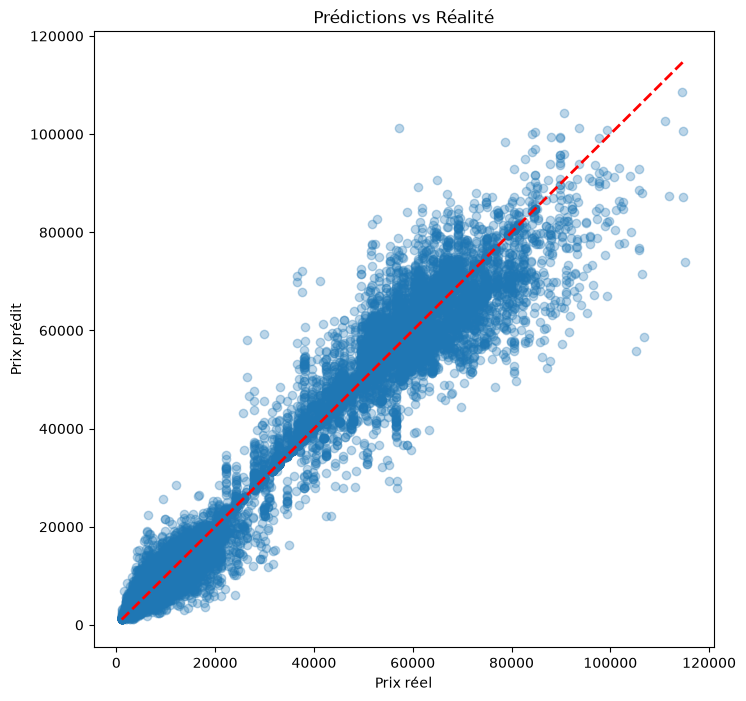

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("Prédictions vs Réalité")
plt.show()

In [37]:
new_flights = pd.DataFrame([
    {
        "airline": "Vistara", "source_city": "Delhi", "departure_time": "Morning",
        "stops": "zero", "arrival_time": "Afternoon", "destination_city": "Mumbai",
        "class": "Economy", "duration": 2.5, "days_left": 15
    },
    {
        "airline": "Vistara", "source_city": "Delhi", "departure_time": "Morning",
        "stops": "zero", "arrival_time": "Afternoon", "destination_city": "Mumbai",
        "class": "Business", "duration": 2.5, "days_left": 15
    },
    {
        "airline": "AirAsia", "source_city": "Delhi", "departure_time": "Morning",
        "stops": "two_or_more", "arrival_time": "Night", "destination_city": "Mumbai",
        "class": "Economy", "duration": 8.0, "days_left": 1
    },
])

new_flights = new_flights[X.columns] 

predictions = final_model.predict(new_flights)

for i, p in enumerate(predictions):
    print(new_flights.iloc[i].to_dict(), "→ prix prédit:", round(p, 2))

{'airline': 'Vistara', 'source_city': 'Delhi', 'departure_time': 'Morning', 'stops': 'zero', 'arrival_time': 'Afternoon', 'destination_city': 'Mumbai', 'class': 'Economy', 'duration': 2.5, 'days_left': 15} → prix prédit: 4527.69
{'airline': 'Vistara', 'source_city': 'Delhi', 'departure_time': 'Morning', 'stops': 'zero', 'arrival_time': 'Afternoon', 'destination_city': 'Mumbai', 'class': 'Business', 'duration': 2.5, 'days_left': 15} → prix prédit: 29477.7
{'airline': 'AirAsia', 'source_city': 'Delhi', 'departure_time': 'Morning', 'stops': 'two_or_more', 'arrival_time': 'Night', 'destination_city': 'Mumbai', 'class': 'Economy', 'duration': 8.0, 'days_left': 1} → prix prédit: 8271.78


In [26]:
absolute_errors = np.abs(y_test - y_pred)

mae = absolute_errors.mean()

print("MAE :", mae)

MAE : 1077.8289017370787


In [27]:
std_error = absolute_errors.std(ddof=1)

n = len(absolute_errors)

standard_error = std_error / np.sqrt(n)

ci_lower = mae - 1.96 * standard_error
ci_upper = mae + 1.96 * standard_error

print("Écart-type :", std_error)
print("Erreur standard :", standard_error)
print(f"Intervalle de confiance à 95% : [{ci_lower:.2f}, {ci_upper:.2f}]")
print(f"On peut affirmer avec 95% de confiance que l'erreur absolue moyenne du modèle "
      f"sur des données similaires se situe entre {ci_lower:.2f} et {ci_upper:.2f}.")

Écart-type : 2570.8799485375152
Erreur standard : 10.492863133509177
Intervalle de confiance à 95% : [1057.26, 1098.39]
On peut affirmer avec 95% de confiance que l'erreur absolue moyenne du modèle sur des données similaires se situe entre 1057.26 et 1098.39.


In [44]:
import joblib

joblib.dump(
    final_model,
    "../artifacts/flight_price_model.joblib",
    compress=3
)

print("Modèle exporté avec succès.")

Modèle exporté avec succès.


In [29]:
import json

metadata = {
    "model": "RandomForestRegressor",
    "target": "price",
    "features": list(X.columns),
    "continuous_variables": continue_variables,
    "discrete_variables": discrete_variables,
    "categories": {col: sorted(X[col].unique().tolist()) for col in discrete_variables},
    "ranges": {col: [float(X[col].min()), float(X[col].max())] for col in continue_variables},
    "train_size": len(X_train),
    "test_size": len(X_test),
    "metrics": {
        "MAE": float(final_mae),
        "RMSE": float(final_rmse),
        "R2": float(final_r2)
    }
}

with open(
    "../artifacts/flight_price_model.meta.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(metadata, f, indent=4)

print("Métadonnées exportées.")

Métadonnées exportées.
